Loading data...
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')
Features being used: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
Calculating optimal K value...

--- Optimal K selected: 26 ---


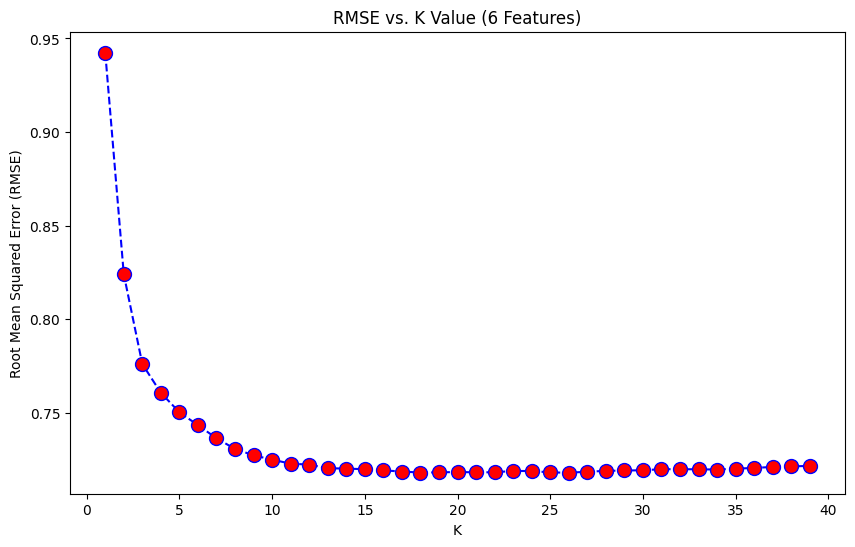


--- Final Model Evaluation ---
Mean Absolute Error (MAE): 0.5109
Mean Squared Error (MSE): 0.5154
Root Mean Squared Error (RMSE): 0.7179

--- Making a Prediction ---
Datas: 8.3252, 41.0, 6.9841, 1.0238, 322.0, 2.5555
Predicted Median House Value: $470,204.54


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ---------------------------------------------------------
# 1. SETUP AND DATA PREPARATION
# ---------------------------------------------------------
print("Loading data...")
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
print(X.columns)

# Drop the spatial features
X = X.drop(columns=['Latitude', 'Longitude'])
print(f"Features being used: {list(X.columns)}")

y = housing.target

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------------
# 2. FINDING THE OPTIMAL K (ELBOW METHOD)
# ---------------------------------------------------------
print("Calculating optimal K value...")
rmse_val = []

# Test K values from 1 to 39
for i in range(1, 40):
    knn_reg = KNeighborsRegressor(n_neighbors=i)
    knn_reg.fit(X_train_scaled, y_train)
    pred_i = knn_reg.predict(X_test_scaled)

    mse = mean_squared_error(y_test, pred_i)
    rmse_val.append(np.sqrt(mse))

# Automatically select the best K (lowest RMSE)
best_k = rmse_val.index(min(rmse_val)) + 1
print(f"\n--- Optimal K selected: {best_k} ---")

# Optional: Show the Elbow Graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 40), rmse_val, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('RMSE vs. K Value (6 Features)')
plt.xlabel('K')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.show()

# ---------------------------------------------------------
# 3. TRAINING THE FINAL MODEL AND EVALUATION
# ---------------------------------------------------------
knn_final = KNeighborsRegressor(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

y_pred = knn_final.predict(X_test_scaled)

print("\n--- Final Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.4f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.4f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

# ---------------------------------------------------------
# 4. MAKING A PREDICTION ON NEW DATA
# ---------------------------------------------------------
# Create a new district matching ONLY the 6 remaining features:
# ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
new_district_data = [[8.3252, 41.0, 6.9841, 1.0238, 322.0, 2.5555]]
new_district_df = pd.DataFrame(new_district_data, columns=X.columns)

# Scale the new data
new_district_scaled = scaler.transform(new_district_df)

# Predict
predicted_value = knn_final.predict(new_district_scaled)
formatted_price = predicted_value[0] * 100000

print("\n--- Making a Prediction ---")
print("Datas: 8.3252, 41.0, 6.9841, 1.0238, 322.0, 2.5555")
print(f"Predicted Median House Value: ${formatted_price:,.2f}")